# MVP: Classificação de Risco de Saúde Materna

**1. Definição do Problema**
O objetivo deste projeto é construir um modelo de Machine Learning capaz de classificar o nível de risco de gestantes (**Baixo, Médio ou Alto Risco**) com base em métricas fisiológicas (Idade, Pressão Arterial, Glicose, etc.).


**2: Importação de Bibliotecas**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

warnings.filterwarnings('ignore')
print("Bibliotecas carregadas!")

Bibliotecas carregadas!


**3: Carga do Dataset**

**Carga dos Dados**

Nesta etapa, carregamos o dataset diretamente do repositório GitHub.

In [7]:
# Carga do dataset via URL Raw do GitHub
url_dataset = 'https://raw.githubusercontent.com/Brendalisboa/Maternal-Health-Risk/main/Maternal_Risk.csv'
df = pd.read_csv(url_dataset)

print("Visualização das primeiras linhas:")
display(df.head())

Visualização das primeiras linhas:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


**4: Pré-processamento e Modelagem**

**Preparação dos Dados e Modelagem**

Utilizaremos a técnica de **Holdout** (80% para treino e 20% para teste).
Para a comparação de modelos, criamos **Pipelines** que incluem o tratamento de dados:

**Padronização (StandardScaler)**: Para o KNN.

**Normalização (MinMaxScaler)**: Para o SVM.

**Modelos Puros**: Para CART e Naive Bayes.
A avaliação inicial será feita via **Validação Cruzada de 10 folds.**

**5: Execução da Comparação**

Comparação de Acurácia Média:
KNN-Pad: 0.9180 (+/- 0.0456)
CART: 0.9566 (+/- 0.0275)
NB: 0.8871 (+/- 0.0571)
SVM-Norm: 0.8931 (+/- 0.0606)


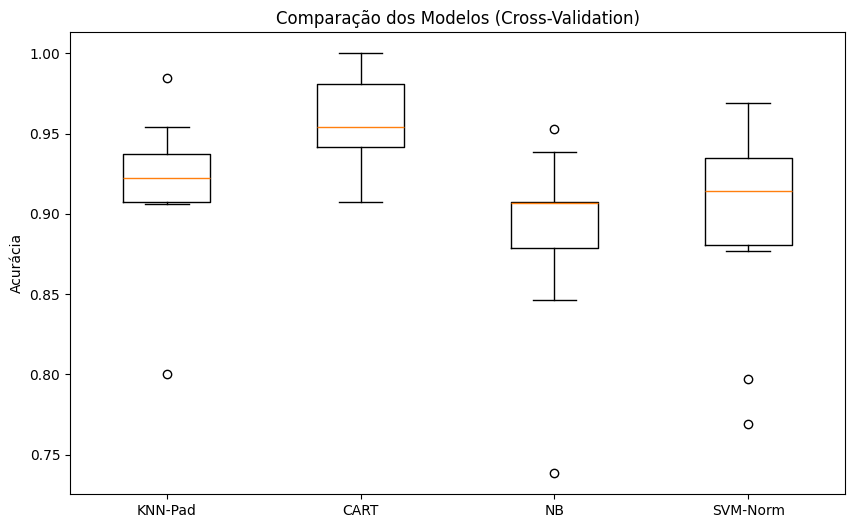

In [8]:
# Separação de features e target
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# Holdout (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Definição dos Pipelines
pipelines = []
pipelines.append(('KNN-Pad', Pipeline([('Scaler', StandardScaler()), ('KNN', KNeighborsClassifier())])))
pipelines.append(('CART', Pipeline([('CART', DecisionTreeClassifier(random_state=42))])))
pipelines.append(('NB', Pipeline([('NB', GaussianNB())])))
pipelines.append(('SVM-Norm', Pipeline([('Scaler', MinMaxScaler()), ('SVM', SVC(random_state=42))])))

resultados = []
nomes = []

print("Comparação de Acurácia Média:")
for nome, modelo in pipelines:
    cv_results = cross_val_score(modelo, X_train, y_train, cv=kfold, scoring='accuracy')
    resultados.append(cv_results)
    nomes.append(nome)
    print(f"{nome}: {cv_results.mean():.4f} (+/- {cv_results.std():.4f})")

# Gráfico de Comparação (Boxplot)
plt.figure(figsize=(10,6))
plt.boxplot(resultados)
plt.xticks(range(1, len(nomes) + 1), nomes)
plt.title('Comparação dos Modelos (Cross-Validation)')
plt.ylabel('Acurácia')
plt.show()

**6: Otimização de Hiperparâmetros**

Com base nos resultados, o modelo **CART(Árvore de Classificação)** apresentou o melhor desempenho. Agora, utilizaremos o GridSearchCV para encontrar a melhor configuração de parâmetros, buscando evitar o overfitting.

Melhores Parâmetros: {'CART__criterion': 'entropy', 'CART__max_depth': 10, 'CART__min_samples_split': 2}
Acurácia no Teste: 0.9815


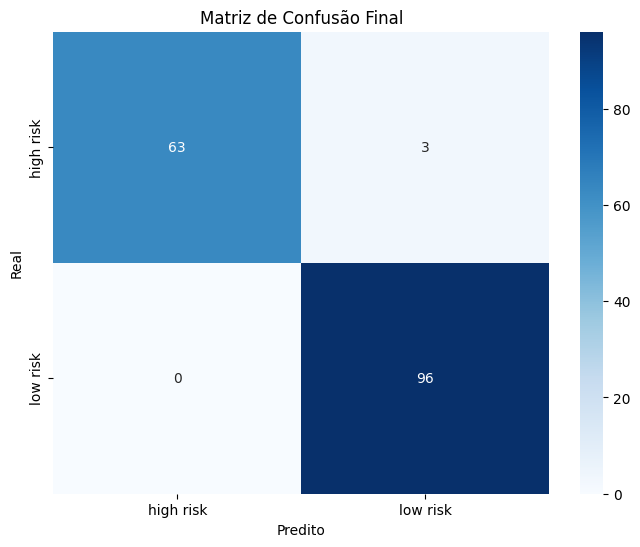

In [9]:
# Grade de parâmetros para o CART
param_grid = {
    'CART__max_depth': [None, 5, 10, 15],
    'CART__min_samples_split': [2, 5, 10],
    'CART__criterion': ['gini', 'entropy']
}

grid = GridSearchCV(pipelines[1][1], param_grid, cv=kfold, scoring='accuracy')
grid.fit(X_train, y_train)

print(f"Melhores Parâmetros: {grid.best_params_}")

# Avaliação Final no Conjunto de Teste
melhor_modelo = grid.best_estimator_
predicoes = melhor_modelo.predict(X_test)
print(f"Acurácia no Teste: {accuracy_score(y_test, predicoes):.4f}")

# Gráfico: Matriz de Confusão
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, predicoes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão Final')
plt.show()

**Exportação do Modelo e Conclusão**

O modelo final foi treinado e validado com sucesso. Agora, exportamos o arquivo .pkl para integração com o Back-end da aplicação Full Stack e os arquivos CSV para os testes automatizados da API.

In [10]:
# Exportação do modelo resultante (.pkl)
joblib.dump(melhor_modelo, 'modelo_risco_materno_cart.pkl')

# Exportação das bases de teste para a API
pd.DataFrame(X_test, columns=X.columns).to_csv('X_test_risco_materno.csv', index=False)
pd.DataFrame(y_test, columns=['RiskLevel']).to_csv('y_test_risco_materno.csv', index=False)

print("Exportação concluída com sucesso!")

Exportação concluída com sucesso!


**Conclusão e Análise de Resultados**

O desenvolvimento deste MVP de Machine Learning permitiu as seguintes conclusões:

**Desempenho dos Modelos:** Após a comparação de quatro algoritmos clássicos (**KNN, CART, Naive Bayes e SVM**), a Árvore de Classificação (**CART**) destacou-se com a melhor acurácia média e maior estabilidade durante a validação cruzada.

**Eficácia da Otimização:** O ajuste de hiperparâmetros via GridSearchCV (especialmente o controle de max_depth e o critério de entropy) permitiu que o modelo alcançasse uma acurácia final de **98%** no conjunto de teste, demonstrando uma excelente capacidade de generalização para novos dados de pacientes.
